In [1]:
#importing the stuff that will be needed for the analysis
from sklearn.metrics import (recall_score, confusion_matrix, roc_auc_score, precision_score, f1_score,
                    accuracy_score, roc_curve, classification_report)
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
#read the dataset using pandas
dataset_test = pd.read_csv('test.csv')
dataset_test 

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,female,male,other,current,ever,former,never,no info,not current
0,2,54,0,0,27.32,6.6,80,0,1,0,0,0,0,0,0,1,0
1,5,76,1,1,20.14,4.8,155,0,0,1,0,1,0,0,0,0,0
2,10,32,0,0,27.32,5.0,100,0,1,0,0,0,0,0,1,0,0
3,17,15,0,0,30.36,6.1,200,0,0,1,0,0,0,0,1,0,0
4,30,43,0,0,26.08,6.1,155,0,0,1,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19218,99962,38,0,0,27.63,4.0,145,0,0,1,0,0,0,0,1,0,0
19219,99980,61,0,0,30.11,6.2,240,1,1,0,0,1,0,0,0,0,0
19220,99988,23,0,0,17.87,5.8,100,0,1,0,0,0,0,0,1,0,0
19221,99992,22,0,0,29.65,6.0,80,0,0,1,0,1,0,0,0,0,0


In [3]:
#read the dataset using pandas
dataset_training = pd.read_csv('train.csv') 
dataset_training

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,female,male,other,current,ever,former,never,no info,not current
0,63066,45,1,0,44.35,4.0,200,0,0,1,0,0,0,1,0,0,0
1,55713,45,0,1,29.95,6.0,158,0,0,1,0,1,0,0,0,0,0
2,76757,57,1,0,30.04,8.2,260,1,0,1,0,0,0,0,0,0,1
3,47140,80,0,0,24.29,6.2,158,0,1,0,0,0,0,0,0,0,1
4,48098,21,0,0,32.92,4.8,140,0,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76884,4327,50,0,0,35.41,4.8,126,0,0,1,0,0,0,0,1,0,0
76885,88698,24,0,0,24.79,6.0,155,0,1,0,0,0,0,0,1,0,0
76886,54442,60,0,0,37.79,6.5,159,1,0,1,0,0,0,1,0,0,0
76887,95902,12,0,0,27.32,6.0,145,0,1,0,0,0,0,0,0,1,0


In [4]:
#scaling the data with the continuous and not the binary columns
binary_cols = [c for c in dataset_training.columns if set(pd.unique(dataset_training[c].dropna())) <= {0, 1}]
cont_cols   = [c for c in dataset_training.columns if c not in binary_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("scale", StandardScaler(), cont_cols),
        ("keep_bin", "passthrough", binary_cols),])

train_scaled_array = preprocess.fit_transform(dataset_training) 
test_scaled_array = preprocess.transform(dataset_test)

new_cols = cont_cols + binary_cols  
train_scaled = pd.DataFrame(train_scaled_array, columns=new_cols, index=dataset_training.index)
test_scaled  = pd.DataFrame(test_scaled_array,  columns=new_cols, index=dataset_test.index)

In [5]:
train_scaled.head() 

,Unnamed: 0,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,diabetes,female,male,other,current,ever,former,never,no info,not current
0,0.476316,0.141014,2.521511,-1.429243,1.514969,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.221570,0.141014,0.390141,0.435572,0.486562,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.950644,0.674635,0.403462,2.486868,2.984121,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,-0.075444,1.697407,-0.447605,0.622053,0.486562,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.042254,-0.926226,0.829736,-0.683317,0.045817,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


Experiment 1: Dropped smoking history

Training X: 76889 rows.
Training Y: 76889 rows.



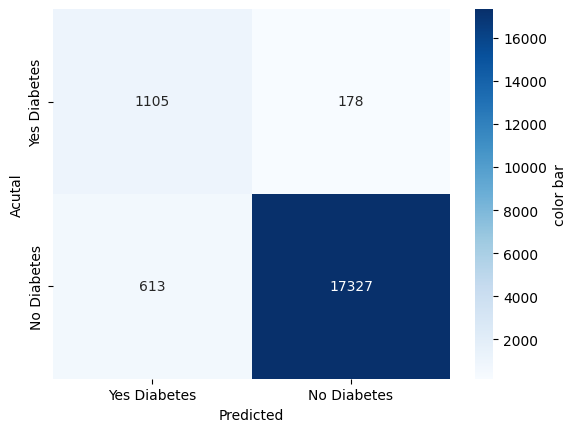


                                0
Accuracy                 0.958851
Sensitivty               0.643190
Specificity              0.989831
AUC                      0.962281
Precision (No Diabetes)  0.965831
F1-Score (No Diabetes)   0.977684
Precision (Diabetes)     0.861263
F1-Score (Diabetes)      0.736421

              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     17505
Yes Diabetes       0.86      0.64      0.74      1718

    accuracy                           0.96     19223
   macro avg       0.91      0.82      0.86     19223
weighted avg       0.96      0.96      0.96     19223



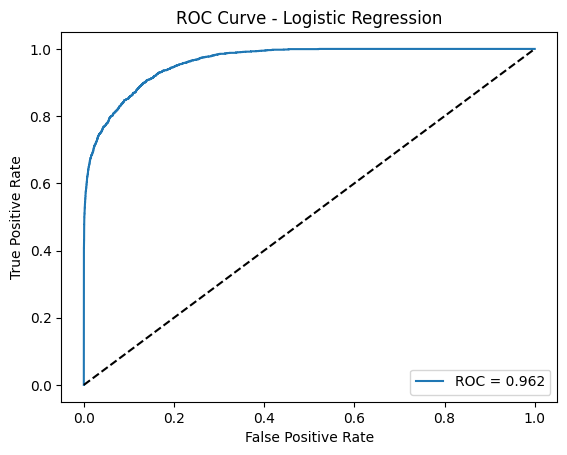

HbA1c_level            2.494667
female                -1.862652
male                  -1.602450
blood_glucose_level    1.365255
age                    1.044087
hypertension           0.801031
heart_disease          0.686958
bmi                    0.602620
dtype: float64


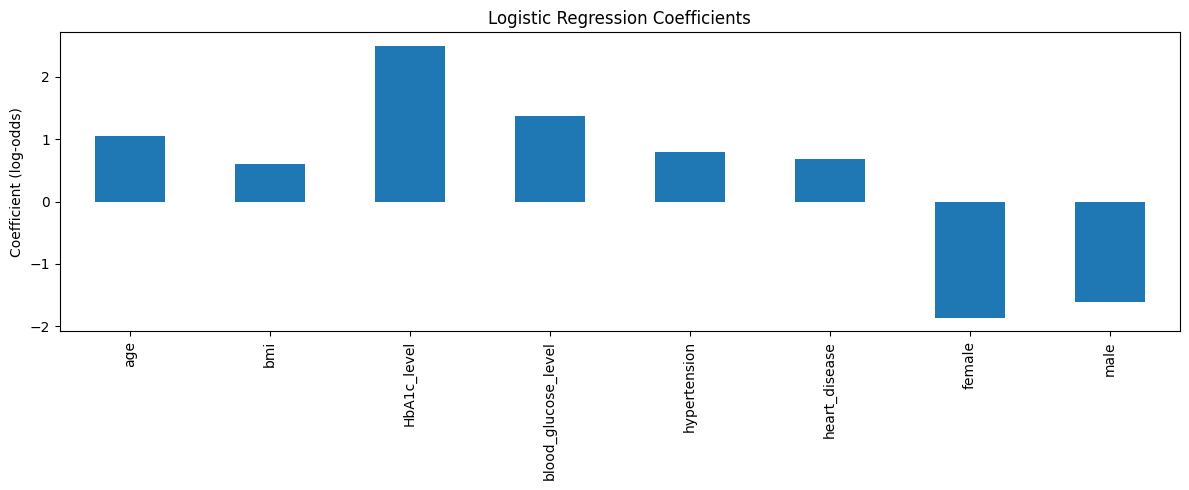

In [6]:
#set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
#dropping irrelevant columns as well because they don't have a large impact on the model
X_train = train_scaled.drop(['diabetes', 'no info', 'not current',
                        'former', 'never', 'ever', 'current', 'Unnamed: 0', 'other'], axis = 1)
X_test  = test_scaled.drop(['diabetes', 'no info', 'former', 'not current',
                        'never', 'ever', 'current', 'Unnamed: 0', 'other'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.') 
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression, basic approach, function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

#generate heatmap for the confusion matrix using seaborn
sns.heatmap((confusion_matrix(y_test, y_pred, labels=[1, 0])).T, cmap="Blues", annot=True, fmt='g', 
    cbar_kws={"orientation":"vertical", "label":"color bar"},xticklabels=["Yes Diabetes", "No Diabetes"],
    yticklabels=["Yes Diabetes", "No Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Acutal")
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show() 

#coefficients for each variable
coef  = pd.Series(lr.coef_[0], index=X_train.columns)
print(coef.sort_values(key=abs, ascending=False))

#coefficients plot for each variable for each gender
coef.plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

Experiment 2: Dropped Diabetes only

Training X: 76889 rows.
Training Y: 76889 rows.



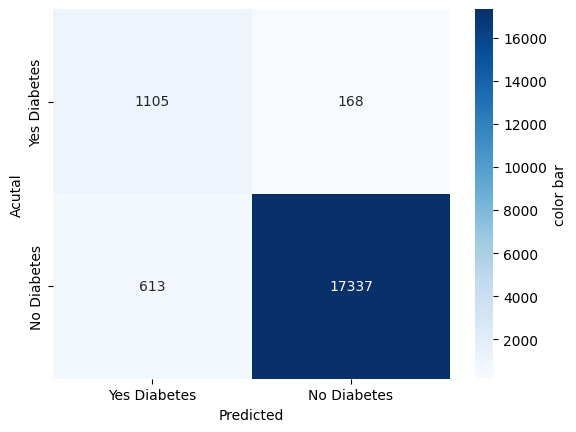



                                0
Accuracy                 0.959372
Sensitivty               0.643190
Specificity              0.990403
AUC                      0.962780
Precision (No Diabetes)  0.965850
F1-Score (No Diabetes)   0.977972
Precision (Diabetes)     0.868028
F1-Score (Diabetes)      0.738883

              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     17505
Yes Diabetes       0.87      0.64      0.74      1718

    accuracy                           0.96     19223
   macro avg       0.92      0.82      0.86     19223
weighted avg       0.96      0.96      0.96     19223



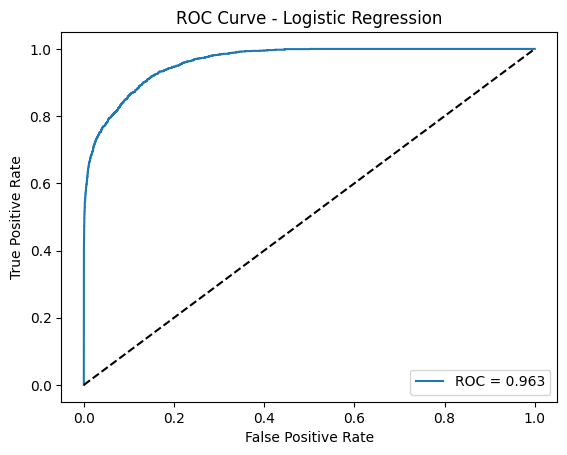

HbA1c_level            2.494624
female                -1.668415
male                  -1.416386
blood_glucose_level    1.362667
age                    1.043237
no info               -0.938397
hypertension           0.745558
heart_disease          0.680549
not current           -0.599196
bmi                    0.588350
never                 -0.481386
former                -0.411151
ever                  -0.376659
current               -0.294086
dtype: float64


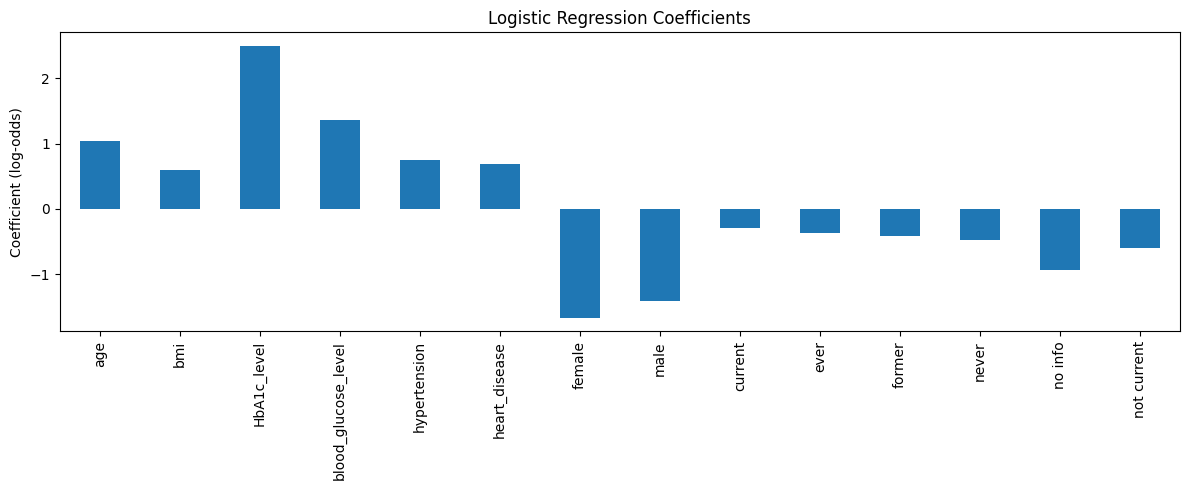

In [7]:
#set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
#dropping irrelevant columns as well because they don't have a large impact on the model
X_train = train_scaled.drop(['diabetes','Unnamed: 0', 'other'], axis = 1)
X_test  = test_scaled.drop(['diabetes','Unnamed: 0', 'other'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.') 
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

#generate heatmap for the confusion matrix using seaborn
sns.heatmap((confusion_matrix(y_test, y_pred, labels=[1, 0])).T, cmap="Blues", annot=True, fmt='g', 
    cbar_kws={"orientation":"vertical", "label":"color bar"},xticklabels=["Yes Diabetes", "No Diabetes"],
    yticklabels=["Yes Diabetes", "No Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Acutal")
plt.show()
print()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')   
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show() 

#coefficients for each variable
coef  = pd.Series(lr.coef_[0], index=X_train.columns)
print(coef.sort_values(key=abs, ascending=False))

#coefficients plot for each variable for each gender
coef.plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()

Experiment 3: Dropped Hypertension

Training X: 76889 rows.
Training Y: 76889 rows.



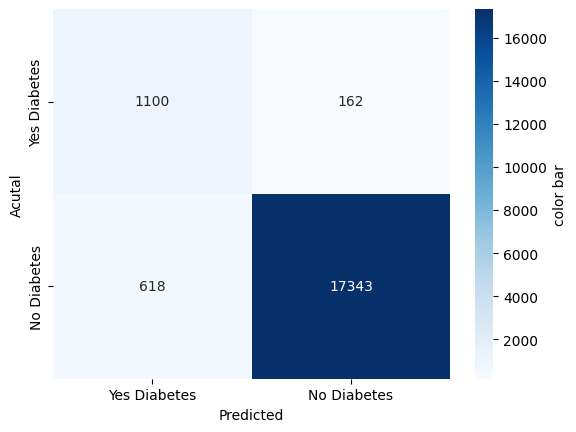


                                0
Accuracy                 0.959424
Sensitivty               0.640279
Specificity              0.990746
AUC                      0.962173
Precision (No Diabetes)  0.965592
F1-Score (No Diabetes)   0.978007
Precision (Diabetes)     0.871632
F1-Score (Diabetes)      0.738255

              precision    recall  f1-score   support

 No Diabetes       0.97      0.99      0.98     17505
Yes Diabetes       0.87      0.64      0.74      1718

    accuracy                           0.96     19223
   macro avg       0.92      0.82      0.86     19223
weighted avg       0.96      0.96      0.96     19223



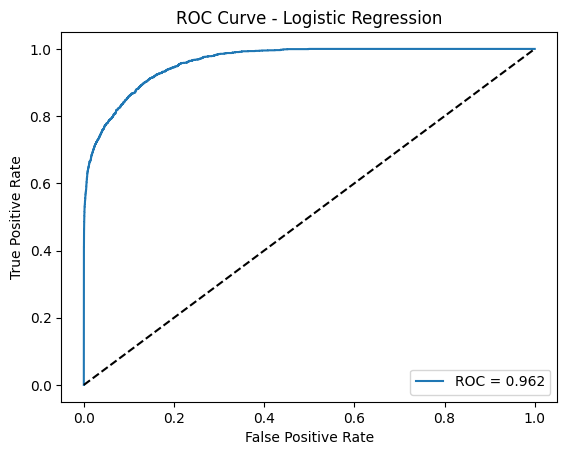

HbA1c_level            2.501567
female                -1.657819
male                  -1.397187
blood_glucose_level    1.361663
age                    1.109108
no info               -0.966516
heart_disease          0.723346
not current           -0.619222
bmi                    0.607878
never                 -0.455390
former                -0.403881
ever                  -0.348811
current               -0.274648
dtype: float64


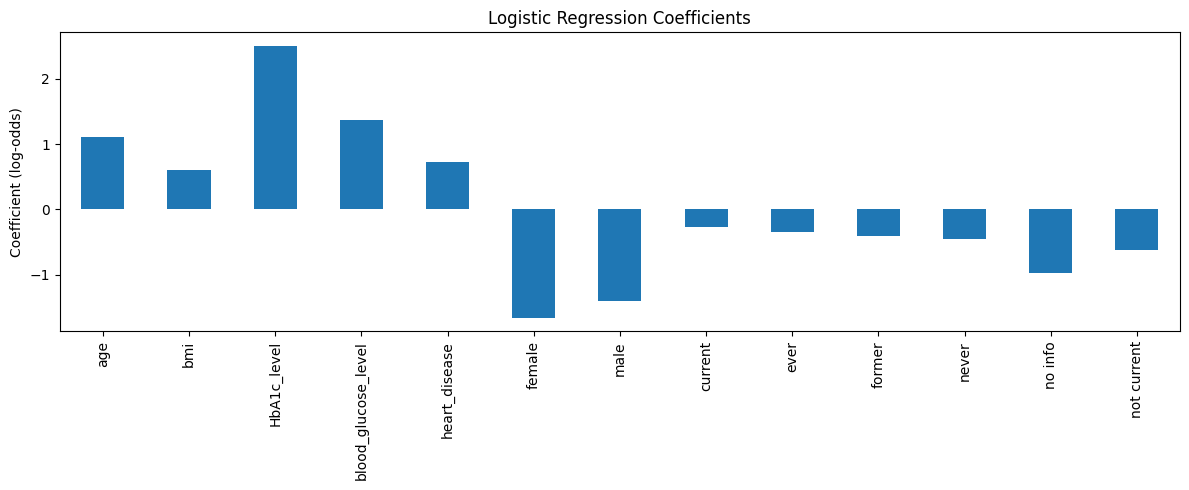

In [8]:
#set the train and test with the y test and train having the target variable of diabetes and the x test and train without it
#dropping irrelevant columns as well because they don't have a large impact on the model
X_train = train_scaled.drop(['diabetes', 'hypertension','Unnamed: 0', 'other'], axis = 1)
X_test  = test_scaled.drop(['diabetes', 'hypertension','Unnamed: 0', 'other'], axis = 1)
y_train = train_scaled['diabetes'] 
y_test  = test_scaled['diabetes']

print(f'Training X: {len(X_train)} rows.') 
print(f'Training Y: {len(y_train)} rows.')
print()

#using the logistic regression function to set the prediction
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)             
y_prob = lr.predict_proba(X_test)[:, 1] 

#doing the confusion matrix, classification report and ROC for metrics we can use for model comparison
accuracy = accuracy_score(y_test, y_pred) 
auc = roc_auc_score(y_test, y_prob)
sensitivity = recall_score(y_test, y_pred)

#generate heatmap for the confusion matrix using seaborn
sns.heatmap((confusion_matrix(y_test, y_pred, labels=[1, 0])).T, cmap="Blues", annot=True, fmt='g', 
    cbar_kws={"orientation":"vertical", "label":"color bar"},xticklabels=["Yes Diabetes", "No Diabetes"],
    yticklabels=["Yes Diabetes", "No Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Acutal")
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
specificity = tn / (tn + fp) 

metrics_summary = {
    'Accuracy': accuracy,
    'Sensitivty': sensitivity,
    'Specificity': specificity,
    'AUC': auc,
    'Precision (No Diabetes)': precision_score(y_test, y_pred, pos_label=0),
    'F1-Score (No Diabetes)': f1_score(y_test, y_pred, pos_label=0),
    'Precision (Diabetes)': precision_score(y_test, y_pred, pos_label=1),
    'F1-Score (Diabetes)': f1_score(y_test, y_pred, pos_label=1)}
print()

metrics_df = pd.DataFrame([metrics_summary])
print(metrics_df.T)
print()

print(classification_report(y_test, y_pred, target_names=['No Diabetes', 'Yes Diabetes']))

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob) 
plt.plot(fpr, tpr, label=f"ROC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

#coefficients for each variable
coef  = pd.Series(lr.coef_[0], index=X_train.columns)
print(coef.sort_values(key=abs, ascending=False))

#coefficients plot for each variable for each gender
coef.plot.bar(figsize=(12,5))
plt.title("Logistic Regression Coefficients")
plt.ylabel("Coefficient (log-odds)")
plt.tight_layout()
plt.show()